# Projet Beans — Classification de maladies des haricots

Pipeline complet : Baseline ML → CNN from scratch → Transfer Learning (MobileNetV2)

**Classes :** `angular_leaf_spot` · `bean_rust` · `healthy`

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report

from src.data_loader import load_beans_tf, load_beans_numpy, CLASS_NAMES
from src.ml_baseline import train_baseline
from src.models import build_mlp_baseline, build_cnn, build_transfer, compile_model
from src.training import train, make_callbacks, data_augmentation
from src.evaluation import (
    diagnose_bias_variance,
    confusion,
    plot_confusion,
    plot_history,
    comparison_table,
)

## 1. Chargement du dataset (TF Datasets)

In [2]:
train_ds, val_ds, test_ds, info = load_beans_tf()

print("Classes :", info.features["label"].names)
for split in ["train", "validation", "test"]:
    print(f"  {split:<12} : {info.splits[split].num_examples} exemples")

README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

c:\Users\abrah\OneDrive\Bureau\IPSSI\beans-project\.venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\abrah\.cache\huggingface\hub\datasets--AI-Lab-Makerere--beans. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

Classes : ['angular_leaf_spot', 'bean_rust', 'healthy']
  train        : 1034 exemples
  validation   : 133 exemples
  test         : 128 exemples


## 2. Visualisation du dataset

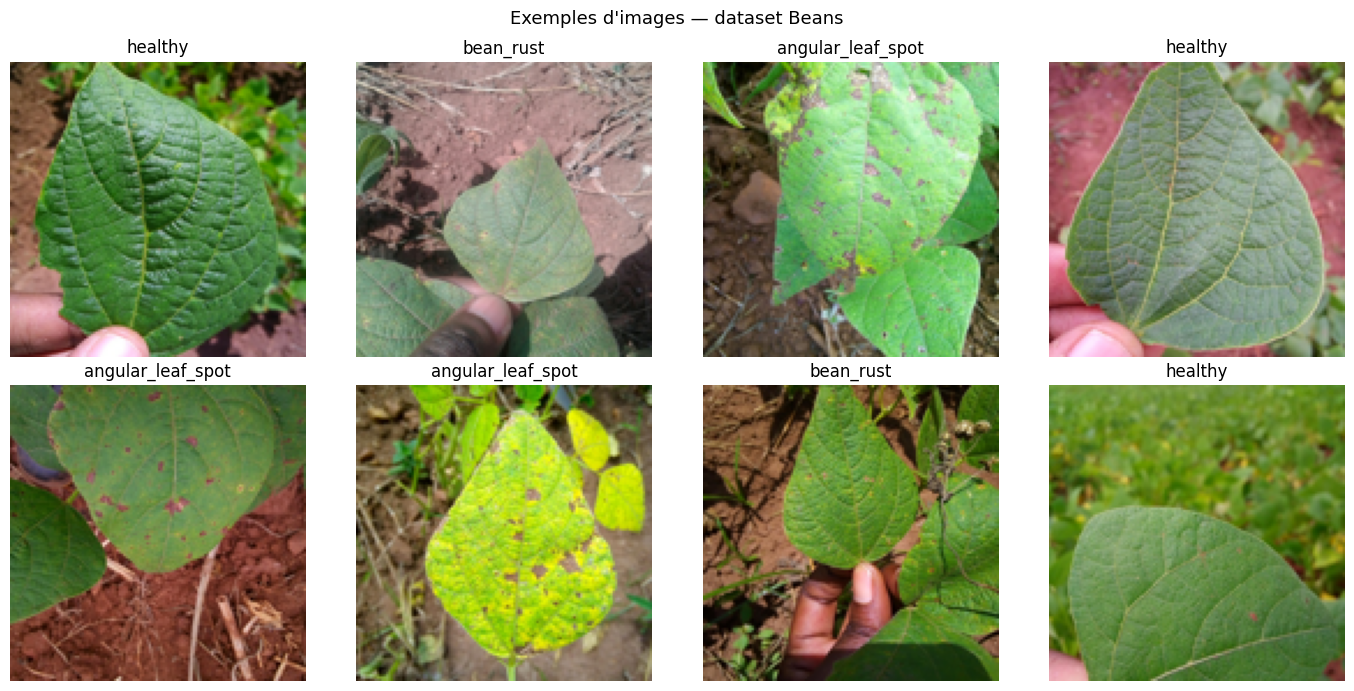

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(CLASS_NAMES[int(labels[i])])
        ax.axis("off")
plt.suptitle("Exemples d'images — dataset Beans", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Chargement NumPy pour la baseline ML

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_beans_numpy()

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}   y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")

X_train : (1034, 12288)   y_train : (1034,)
X_val   : (133, 12288)   y_val   : (133,)
X_test  : (128, 12288)   y_test  : (128,)


## 4. Baseline ML — Logistic Regression (L2)

In [ ]:
result_lr = train_baseline(
    X_train, y_train, X_val, y_val,
    penalty="l2", C=1.0,
    X_test=X_test, y_test=y_test,
)

print(f"Train acc : {result_lr.train_acc:.3f}")
print(f"Val acc   : {result_lr.val_acc:.3f}")
print(f"Test acc  : {result_lr.test_acc:.3f}")
print(f"F1 macro  : {result_lr.f1_macro:.3f}")
print()
print(diagnose_bias_variance(result_lr.train_acc, result_lr.val_acc))

In [ ]:
lr_model = result_lr.extra["model"]
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=CLASS_NAMES))

## 5. Préparation du dataset Deep Learning

`load_beans_tf()` applique déjà le **resize** (128×128), la **normalisation** [0, 1] et le **batching** (32).  
On ajoute une couche d'**augmentation** sur le train set pour réduire le surapprentissage.

In [ ]:
aug = data_augmentation()

train_ds_aug = train_ds.map(
    lambda x, y: (aug(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE,
)

## 6. CNN from scratch

In [ ]:
cnn = build_cnn(img_size=128, num_classes=3)
cnn = compile_model(cnn)
cnn.summary()

In [ ]:
history_cnn = train(cnn, train_ds_aug, val_ds, epochs=30)

## 7. Évaluation du CNN

In [ ]:
plot_history(history_cnn)
plt.suptitle("CNN from scratch — courbes d'apprentissage")
plt.tight_layout()
plt.show()

y_pred_cnn, y_true_cnn = [], []
for images, labels in test_ds:
    preds = cnn.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds, axis=1))
    y_true_cnn.extend(labels.numpy())

y_pred_cnn = np.array(y_pred_cnn)
y_true_cnn = np.array(y_true_cnn)

cm_cnn, report_cnn = confusion(y_true_cnn, y_pred_cnn, class_names=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(cm_cnn, CLASS_NAMES, ax=ax, title="CNN — Matrice de confusion")
plt.tight_layout()
plt.show()

print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_NAMES))
print(diagnose_bias_variance(
    history_cnn.history["accuracy"][-1],
    history_cnn.history["val_accuracy"][-1],
))

## 8. Transfer Learning — MobileNetV2

In [ ]:
transfer = build_transfer(img_size=128, num_classes=3, trainable_base=False)
transfer = compile_model(transfer)
transfer.summary()

In [ ]:
history_transfer = train(transfer, train_ds_aug, val_ds, epochs=30)

## 9. Évaluation du Transfer Learning

In [ ]:
plot_history(history_transfer)
plt.suptitle("Transfer Learning MobileNetV2 — courbes d'apprentissage")
plt.tight_layout()
plt.show()

y_pred_tr, y_true_tr = [], []
for images, labels in test_ds:
    preds = transfer.predict(images, verbose=0)
    y_pred_tr.extend(np.argmax(preds, axis=1))
    y_true_tr.extend(labels.numpy())

y_pred_tr = np.array(y_pred_tr)
y_true_tr = np.array(y_true_tr)

cm_tr, report_tr = confusion(y_true_tr, y_pred_tr, class_names=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(cm_tr, CLASS_NAMES, ax=ax, title="Transfer Learning — Matrice de confusion")
plt.tight_layout()
plt.show()

print(classification_report(y_true_tr, y_pred_tr, target_names=CLASS_NAMES))
print(diagnose_bias_variance(
    history_transfer.history["accuracy"][-1],
    history_transfer.history["val_accuracy"][-1],
))

## 10. Comparaison finale : ML vs CNN vs Transfer Learning

In [ ]:
rows = [
    {
        "modele": result_lr.name,
        "test_acc": result_lr.test_acc,
        "f1_macro": result_lr.f1_macro,
        "params": X_train.shape[1] * 3,
        "temps_s": "rapide",
    },
    {
        "modele": "CNN from scratch",
        "test_acc": report_cnn["accuracy"],
        "f1_macro": report_cnn["macro avg"]["f1-score"],
        "params": cnn.count_params(),
        "temps_s": "moyen",
    },
    {
        "modele": "Transfer MobileNetV2",
        "test_acc": report_tr["accuracy"],
        "f1_macro": report_tr["macro avg"]["f1-score"],
        "params": transfer.count_params(),
        "temps_s": "moyen",
    },
]

df = comparison_table(rows)
df